# ======================================================================
# MODULE 4: DCT-QIM Embedding (Compression-Resilient Video Steganography)
# ======================================================================
#
# **Project:** QVSC — Quantum-assisted Video Steganographic Communication
#
# **Purpose:** Hide encrypted ciphertext bits inside cover video frames
# using DCT-domain Quantization Index Modulation (QIM). The embedding
# targets the Y (luminance) channel of YCrCb color space, using
# low-frequency DCT coefficients that survive H.264 compression while
# remaining visually imperceptible.
#
# **This is the CORE NOVEL contribution of the QVSC thesis** — combining
# quantum-derived encryption with compression-resilient DCT-QIM embedding
# and adaptive ROI masking in video.
#
# **Input:**
# - `fec_payload.bin` — FEC-protected encrypted payload (Module 2 ciphertext
#                       wrapped with Reed-Solomon + interleaving)
# - `roi_masks.npy` — ROI block masks from Module 3
# - `video_metadata.npy` — Video parameters from Module 3
# - Cover video file (e.g., `cover_video.mp4`)
#
# **Output:**
# - `stego_raw.avi` — Stego video (uncompressed, before H.264)
# - `stego_compressed.mp4` — Stego video (H.264 compressed)
# - Embedding statistics and quality metrics
#
# **Algorithm:**
# ```
# 1. Load ciphertext bitstream from Module 2
# 2. Load ROI masks from Module 3
# 3. Load cover video frames
# 4. For each frame:
#    a. Convert BGR → YCrCb
#    b. Extract Y channel (luminance — survives H.264 chroma subsampling)
#    c. Divide Y (luminance) into 8×8 blocks
#    d. For each block where ROI mask = 1 (and bits remain):
#       i.   Apply 2D DCT to the block
#       ii.  Select low-frequency coefficient at position (2,2)
#       iii. Apply QIM: c' = Δ×round(c/Δ) + (-1)^(1-b) × (Δ/4)
#       iv.  Apply inverse DCT (IDCT)
#    e. Reconstruct Y channel from modified blocks
#    f. Merge modified Y with original Cr, Cb → YCrCb frame
#    g. Convert YCrCb → BGR
# 5. Write all frames to stego_raw.avi (uncompressed)
# 6. Compress with FFmpeg H.264 → stego_compressed.mp4
# ```
#
# **Key Equations:**
#   DCT:  F(u,v) = (1/4)×C(u)×C(v)×ΣΣ f(x,y)×cos[(2x+1)uπ/16]×cos[(2y+1)vπ/16]
#   QIM:  c' = Δ×round(c/Δ) + (-1)^(1-b) × (Δ/4)
#   Extract: b = 1 if (c - round(c/Δ)×Δ) > 0, else b = 0
#
# **Tools:** OpenCV, NumPy, SciPy (DCT), FFmpeg
#
# ======================================================================

## Section 1: Library Imports

In [1]:
import cv2
import numpy as np
from scipy.fft import dctn, idctn
import matplotlib.pyplot as plt
import os
import subprocess
import struct

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2: Configuration and Parameters

All critical embedding parameters are defined here in one place.
These MUST be shared with Module 5 (extraction) — if even one
parameter differs, extraction will fail.

In [2]:
# ── File paths (inputs from previous modules) ─────────────────────────
# CIPHERTEXT_FILE   = 'ciphertext.bin'        # From Module 2
CIPHERTEXT_FILE   = 'fec_payload.bin'        # From Module 2
ROI_MASKS_FILE    = 'roi_masks.npy'          # From Module 3
VIDEO_META_FILE   = 'video_metadata.npy'     # From Module 3
COVER_VIDEO_PATH  = 'cover_video.mp4'        # Original cover video

# ── Output paths ──────────────────────────────────────────────────────
STEGO_RAW_PATH    = 'stego_raw.avi'          # Uncompressed stego output
STEGO_COMPRESSED  = 'stego_compressed.mp4'   # H.264 compressed output

# ── DCT-QIM parameters ────────────────────────────────────────────────
# CHANGED for compression resilience (see why below):
#   EMBED_CHANNEL 1->0 : embed in Y (luminance), NOT Cr. In 4:2:0 H.264,
#                        the Cr plane is subsampled to half resolution,
#                        which decimates any high-frequency chroma detail
#                        and destroys the payload. Y is kept at full
#                        resolution, so it survives compression.
#   COEFF_POS (4,5)->(2,2) : a low-frequency coefficient. H.264 quantizes
#                        high-frequency coefficients hardest, so (4,5) was
#                        the first thing thrown away. (2,2) survives.
#   QIM_DELTA 25->50 : wider quantization step => bigger error margin
#                        (survives perturbation up to Delta/4 = 12.5).
EMBED_CHANNEL     = 0             # 0 = Y (luminance), 1 = Cr, 2 = Cb
BLOCK_SIZE        = 8             # DCT block size (standard 8×8)
COEFF_POS         = (2, 2)        # Low-frequency DCT coefficient position
QIM_DELTA         = 50            # QIM quantization step (Δ)

# ── H.264 compression parameters ─────────────────────────────────────
# CHANGED: use constant QP, NOT CRF. CRF is a rate-control mode that VARIES
# the quantizer frame-to-frame (mb-tree lowers quality on frames it deems
# redundant) — that destroyed the embedded coefficient on every frame after
# the first. Constant QP quantizes every frame identically, so all frames
# survive. QP is also the right controlled variable for a robustness study.
QP_VALUE          = 23            # Constant quantizer (18=high quality, 28=low)
H264_PRESET       = 'medium'      # FFmpeg preset (ultrafast..veryslow)
INTRA_ONLY        = True          # Every frame an I-frame (keyint=1): no
                                  # inter-prediction to drift the coefficient.

# ── Informed-embedding parameter ─────────────────────────────────────
# The BGR<->YCrCb<->uint8 color round-trip is not bit-exact, so naive
# embedding leaves a small residual BER even BEFORE compression. Because the
# payload is AEAD-encrypted (one wrong bit => whole message rejected), the
# embedding must be exactly invertible. Informed embedding simulates the
# round-trip, finds blocks that decode wrong, and pre-distorts them until
# every block reads back correctly. Drives pre-compression BER to 0%.
MAX_EMBED_ITER    = 15            # Max pre-distortion passes per frame

CHAN_NAME = {0: 'Y (luminance)', 1: 'Cr (red chroma)', 2: 'Cb (blue chroma)'}

print("="*70)
print("  MODULE 4 CONFIGURATION")
print("="*70)
print(f"  Embedding channel:   {EMBED_CHANNEL} = {CHAN_NAME[EMBED_CHANNEL]}")
print(f"  Block size:          {BLOCK_SIZE}×{BLOCK_SIZE}")
print(f"  DCT coeff position:  {COEFF_POS} (low-frequency)")
print(f"  QIM Δ (delta):       {QIM_DELTA}")
print(f"  H.264 QP:            {QP_VALUE}")
print(f"  H.264 preset:        {H264_PRESET}")
print(f"  Intra-only encoding: {INTRA_ONLY}")
print("="*70)


  MODULE 4 CONFIGURATION
  Embedding channel:   0 = Y (luminance)
  Block size:          8×8
  DCT coeff position:  (2, 2) (low-frequency)
  QIM Δ (delta):       50
  H.264 QP:            23
  H.264 preset:        medium
  Intra-only encoding: True


## Section 3: Load Inputs from Previous Modules

Module 4 consumes outputs from both Module 2 (encrypted payload) and
Module 3 (ROI masks + video metadata). We also reload the cover video
frames for modification.

In [3]:
# ── 3a: Load ciphertext bitstream from Module 2 ───────────────────────
with open(CIPHERTEXT_FILE, 'rb') as f:
    ciphertext_blob = f.read()

# Convert bytes to a list of individual bits (0s and 1s)
# Each byte becomes 8 bits, MSB first
payload_bits = []
for byte in ciphertext_blob:
    for bit_pos in range(7, -1, -1):          # MSB first
        payload_bits.append((byte >> bit_pos) & 1)

payload_bits = np.array(payload_bits, dtype=np.uint8)

print(f"Ciphertext loaded from '{CIPHERTEXT_FILE}'")
print(f"  File size:     {len(ciphertext_blob)} bytes")
print(f"  Payload bits:  {len(payload_bits)}")
print(f"  First 32 bits: {''.join(map(str, payload_bits[:32]))}")

Ciphertext loaded from 'fec_payload.bin'
  File size:     99450 bytes
  Payload bits:  795600
  First 32 bits: 00000000111101000010001101100101


In [4]:
# ── 3b: Load ROI masks from Module 3 ──────────────────────────────────
roi_masks = np.load(ROI_MASKS_FILE)
video_meta = np.load(VIDEO_META_FILE, allow_pickle=True).item()

print(f"ROI masks loaded from '{ROI_MASKS_FILE}'")
print(f"  Shape:          {roi_masks.shape} (frames × blocks_y × blocks_x)")
print(f"  Total ROI blocks: {int(np.sum(roi_masks))}")
print(f"")
print(f"Video metadata from '{VIDEO_META_FILE}':")
for k, v in video_meta.items():
    print(f"  {k:18s}: {v}")

ROI masks loaded from 'roi_masks.npy'
  Shape:          (425, 135, 240) (frames × blocks_y × blocks_x)
  Total ROI blocks: 3977980

Video metadata from 'video_metadata.npy':
  fps               : 30.0
  frame_width       : 1920
  frame_height      : 1080
  total_frames      : 425
  block_size        : 8
  blocks_y          : 135
  blocks_x          : 240
  total_roi_blocks  : 3977980
  canny_low         : 50
  canny_high        : 150
  blur_sigma        : 1.0
  dilate_iters      : 2
  edge_threshold    : 0.3
  cover_video       : cover_video.mp4


In [5]:
# ── 3c: Load cover video frames ───────────────────────────────────────
def extract_frames(video_path, max_frames=None):
    """
    Extract frames from a video file as a list of NumPy arrays (BGR).
    Same function used in Module 3 for consistency.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")
    
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    frames = []
    count  = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
        count += 1
        if max_frames and count >= max_frames:
            break
    cap.release()
    return frames, fps, width, height

cover_frames, fps, frame_w, frame_h = extract_frames(
    COVER_VIDEO_PATH, max_frames=roi_masks.shape[0]
)

print(f"Cover video loaded: '{COVER_VIDEO_PATH}'")
print(f"  Frames:     {len(cover_frames)}")
print(f"  Resolution: {frame_w}×{frame_h}")
print(f"  FPS:        {fps}")

Cover video loaded: 'cover_video.mp4'
  Frames:     425
  Resolution: 1920×1080
  FPS:        30.0


In [6]:
# ── 3d: Capacity check — does the payload fit? ────────────────────────
total_roi_blocks = int(np.sum(roi_masks))
total_capacity   = total_roi_blocks           # 1 bit per ROI block
payload_size     = len(payload_bits)

print("="*70)
print("  CAPACITY CHECK")
print("="*70)
print(f"  Available ROI blocks:  {total_roi_blocks}")
print(f"  Payload size (bits):   {payload_size}")
print(f"  Utilization:           {payload_size/total_capacity*100:.1f}%")

if payload_size <= total_capacity:
    print(f"  ✓ Payload FITS — {total_capacity - payload_size} spare bits remaining")
else:
    print(f"  ✗ PAYLOAD TOO LARGE — need {payload_size - total_capacity} more ROI blocks")
    print(f"    → Reduce message, lower edge threshold, or use more frames")
print("="*70)

  CAPACITY CHECK
  Available ROI blocks:  3977980
  Payload size (bits):   795600
  Utilization:           20.0%
  ✓ Payload FITS — 3182380 spare bits remaining


## Section 4: DCT and QIM Core Functions

This section implements the mathematical heart of the steganography system.

### 4.1 — 2D Discrete Cosine Transform (DCT)
The DCT converts an 8×8 pixel block from the spatial domain into the
frequency domain. The result is an 8×8 matrix of coefficients where:
- Position (0,0) is the **DC coefficient** (average brightness) — never modify
- Low positions (0-2) are **low-frequency** — visible if changed
- High positions (6-7) are **high-frequency** — destroyed by compression
- Mid positions (3-5) are the **sweet spot** — survive compression, minimal visual impact

We use position **(2,2)** — a low-frequency coefficient. H.264 quantizes
high-frequency coefficients most aggressively, so a low-frequency position
survives compression far better. We avoid the DC term (0,0) and the most
perceptually sensitive lowest positions; the small per-block change is
further hidden by embedding only in textured ROI blocks.

### 4.2 — Quantization Index Modulation (QIM)
QIM embeds a bit by quantizing a DCT coefficient to one of two interleaved
quantization lattices, separated by Δ/2:

```
Embedding:  c' = Δ × round(c/Δ) + (-1)^(1-b) × (Δ/4)
Extraction: b = 1 if (c' - round(c'/Δ)×Δ) > 0, else b = 0
```

The parameter Δ controls the trade-off:
- **Large Δ (e.g., 50):** More robust against compression, but more visible
- **Small Δ (e.g., 10):** Less visible, but bits may flip after compression
- **Δ = 50** is our value — with *informed embedding* it gives 0%
  pre-compression BER, and any residual after compression is cleaned up
  by the Reed-Solomon FEC layer (decoded in Module 6)

In [7]:
def apply_dct_2d(block):
    """
    Apply 2D Type-II DCT to an 8×8 block.
    
    The DCT transforms spatial-domain pixel values into frequency-domain
    coefficients. We use scipy's dctn which computes the multi-dimensional
    DCT efficiently.
    
    Parameters:
        block : np.ndarray (8, 8) — pixel values (float64)
    
    Returns:
        dct_block : np.ndarray (8, 8) — DCT coefficients
    """
    return dctn(block, type=2, norm='ortho')


def apply_idct_2d(dct_block):
    """
    Apply 2D inverse DCT (IDCT) to reconstruct the spatial block
    from DCT coefficients.
    
    Parameters:
        dct_block : np.ndarray (8, 8) — DCT coefficients
    
    Returns:
        block : np.ndarray (8, 8) — reconstructed pixel values
    """
    return idctn(dct_block, type=2, norm='ortho')


def qim_embed_bit(coeff, bit, delta):
    """
    Embed a single bit into a DCT coefficient using QIM.
    
    The QIM formula creates two interleaved quantization lattices:
      - Lattice 0 (bit=0): quantized value - Δ/4
      - Lattice 1 (bit=1): quantized value + Δ/4
    
    This separation of Δ/2 between lattices provides robustness against
    noise and compression — as long as the perturbation is less than Δ/4,
    the correct bit can be recovered.
    
    Parameters:
        coeff : float — original DCT coefficient c
        bit   : int (0 or 1) — secret bit to embed
        delta : float — quantization step Δ
    
    Returns:
        modified_coeff : float — modified DCT coefficient c'
    """
    # Quantize to nearest multiple of delta
    quantized = delta * np.round(coeff / delta)
    
    # Shift based on the secret bit
    # bit=1 → shift right (+Δ/4), bit=0 → shift left (-Δ/4)
    modified = quantized + ((-1) ** (1 - bit)) * (delta / 4)
    
    return modified


def qim_extract_bit(coeff, delta):
    """
    Extract a single bit from a (possibly noisy) DCT coefficient using QIM.
    
    The extraction checks which lattice the coefficient is closer to:
    - If the remainder (c - nearest_multiple) > 0 → bit = 1
    - If the remainder ≤ 0 → bit = 0
    
    Parameters:
        coeff : float — DCT coefficient (possibly modified by compression)
        delta : float — quantization step Δ (must match embedding)
    
    Returns:
        bit : int (0 or 1) — extracted secret bit
    """
    quantized = delta * np.round(coeff / delta)
    remainder = coeff - quantized
    
    return 1 if remainder > 0 else 0


print("DCT and QIM functions defined.")

DCT and QIM functions defined.


In [8]:
# ── Quick verification: embed and extract a test bit ──────────────────
# This confirms the QIM math works correctly before running on video

print("QIM Verification (no compression):")
print(f"  Δ = {QIM_DELTA}")
print(f"  {'Original':>10} | {'Bit':>3} | {'Modified':>10} | {'Extracted':>9} | {'Match':>5}")
print(f"  {'-'*10}-+-{'-'*3}-+-{'-'*10}-+-{'-'*9}-+-{'-'*5}")

test_coeffs = [-47.3, 0.0, 12.8, 50.0, -25.0, 100.7, -3.14]
all_pass = True
for c in test_coeffs:
    for b in [0, 1]:
        c_mod = qim_embed_bit(c, b, QIM_DELTA)
        b_ext = qim_extract_bit(c_mod, QIM_DELTA)
        match = '✓' if b_ext == b else '✗'
        if b_ext != b:
            all_pass = False
        print(f"  {c:>10.2f} | {b:>3} | {c_mod:>10.2f} | {b_ext:>9} | {match:>5}")

print(f"\n  Overall: {'✓ ALL PASS' if all_pass else '✗ SOME FAILED'}")

QIM Verification (no compression):
  Δ = 50
    Original | Bit |   Modified | Extracted | Match
  -----------+-----+------------+-----------+------
      -47.30 |   0 |     -62.50 |         0 |     ✓
      -47.30 |   1 |     -37.50 |         1 |     ✓
        0.00 |   0 |     -12.50 |         0 |     ✓
        0.00 |   1 |      12.50 |         1 |     ✓
       12.80 |   0 |     -12.50 |         0 |     ✓
       12.80 |   1 |      12.50 |         1 |     ✓
       50.00 |   0 |      37.50 |         0 |     ✓
       50.00 |   1 |      62.50 |         1 |     ✓
      -25.00 |   0 |     -12.50 |         0 |     ✓
      -25.00 |   1 |      12.50 |         1 |     ✓
      100.70 |   0 |      87.50 |         0 |     ✓
      100.70 |   1 |     112.50 |         1 |     ✓
       -3.14 |   0 |     -12.50 |         0 |     ✓
       -3.14 |   1 |      12.50 |         1 |     ✓

  Overall: ✓ ALL PASS


## Section 5: Single-Frame Embedding Function

This function embeds a portion of the payload bitstream into a single
video frame. It processes the **Y (luminance) channel**. Y is more
perceptually sensitive than chroma, but it is NOT subsampled by H.264
4:2:0 (chroma is halved), so embedding in Y is what lets the payload
survive compression. The visibility cost is kept small by embedding only
in textured ROI blocks and by using *informed embedding*.

The process for each eligible 8×8 block:
1. Convert the block pixels to float64 (needed for DCT precision)
2. Apply 2D DCT → get frequency coefficients
3. Read the coefficient at position (2,2)
4. Apply QIM to embed one secret bit
5. Apply inverse DCT → reconstruct the pixel block, clip to [0, 255]

Then an **informed-embedding** pass simulates the exact YCrCb↔BGR↔uint8
round-trip the receiver will perform, finds any block that decodes to the
wrong bit, and pre-distorts it until every block reads back correctly —
driving the pre-compression BER to exactly 0%.

In [9]:
def embed_in_frame(frame_bgr, block_mask, payload_bits, bit_index,
                   block_size=8, coeff_pos=(2, 2), delta=50, channel=0,
                   max_iter=15):
    """
    Embed payload bits into one frame using DCT-QIM with INFORMED EMBEDDING.

    Why informed embedding: writing a frame as 8-bit BGR and reading it back
    is not bit-exact (the YCrCb<->BGR<->uint8 round-trip perturbs every DCT
    coefficient slightly). Naive embedding therefore leaves a small residual
    BER even with no compression — fatal for an AEAD payload, where a single
    wrong bit rejects the whole message. So after embedding we SIMULATE the
    exact round-trip the extractor performs, find any block that decodes to
    the wrong bit, and PRE-DISTORT its coefficient to compensate. A few
    passes drive the pre-compression BER to exactly 0%.

    Returns: (stego_frame_bgr, updated_bit_index, bits_embedded)
    """
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    chan  = ycrcb[:, :, channel].astype(np.float64)
    blocks_y, blocks_x = block_mask.shape
    u, v = coeff_pos

    # ---- Pass 1: standard QIM embed, recording which block holds which bit ----
    assignments = []  # list of (y_start, x_start, target_bit)
    for by in range(blocks_y):
        for bx in range(blocks_x):
            if bit_index >= len(payload_bits):
                break
            if block_mask[by, bx] == 0:
                continue
            ys, xs = by * block_size, bx * block_size
            blk = chan[ys:ys+block_size, xs:xs+block_size]
            dct_blk = apply_dct_2d(blk)
            bit = int(payload_bits[bit_index])
            dct_blk[u, v] = qim_embed_bit(dct_blk[u, v], bit, delta)
            chan[ys:ys+block_size, xs:xs+block_size] = np.clip(apply_idct_2d(dct_blk), 0, 255)
            assignments.append((ys, xs, bit))
            bit_index += 1
        if bit_index >= len(payload_bits):
            break

    # ---- Informed passes: simulate the round-trip and fix wrong blocks ----
    for _ in range(max_iter):
        ycrcb[:, :, channel] = np.round(np.clip(chan, 0, 255)).astype(np.uint8)
        # exact round-trip the extractor will see: YCrCb -> BGR -> YCrCb (uint8)
        roundtrip = cv2.cvtColor(
            cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR),
            cv2.COLOR_BGR2YCrCb)[:, :, channel].astype(np.float64)

        wrong = []
        for (ys, xs, bit) in assignments:
            obs = apply_dct_2d(roundtrip[ys:ys+block_size, xs:xs+block_size])[u, v]
            if qim_extract_bit(obs, delta) != bit:
                wrong.append((ys, xs, bit))

        if not wrong:
            break  # every block decodes correctly — done

        # Pre-distort each failing block by the observed round-trip gap
        for (ys, xs, bit) in wrong:
            obs = apply_dct_2d(roundtrip[ys:ys+block_size, xs:xs+block_size])[u, v]
            q = delta * np.round(obs / delta)
            correct_point = q + (1 if bit else -1) * (delta / 4)
            work = apply_dct_2d(chan[ys:ys+block_size, xs:xs+block_size])
            work[u, v] += (correct_point - obs)   # shift to compensate
            chan[ys:ys+block_size, xs:xs+block_size] = np.clip(apply_idct_2d(work), 0, 255)

    # Final write-back
    ycrcb[:, :, channel] = np.round(np.clip(chan, 0, 255)).astype(np.uint8)
    stego_frame = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)
    return stego_frame, bit_index, len(assignments)


print("Single-frame INFORMED embedding function defined.")


Single-frame INFORMED embedding function defined.


## Section 6: Embed Payload Across All Frames

Now we iterate over all video frames and embed the full payload bitstream.
The embedding proceeds in raster order: frame 0 first, then frame 1, etc.
Within each frame, blocks are scanned left-to-right, top-to-bottom.

Once all payload bits are embedded, remaining frames are left unmodified
(copied as-is). This minimizes the number of modified frames.

In [10]:
# ── Embed across all frames ───────────────────────────────────────────
stego_frames = []
bit_index    = 0
frame_stats  = []     # Track per-frame embedding statistics

print("Embedding payload into cover video...")
print("-"*70)

for i, frame in enumerate(cover_frames):
    if bit_index >= len(payload_bits):
        # All bits embedded — copy remaining frames unchanged
        stego_frames.append(frame.copy())
        frame_stats.append({'frame': i, 'bits_embedded': 0, 'status': 'unchanged'})
    else:
        # Embed bits in this frame
        stego_frame, bit_index, bits_in_frame = embed_in_frame(
            frame, roi_masks[i], payload_bits, bit_index,
            block_size=BLOCK_SIZE, coeff_pos=COEFF_POS, delta=QIM_DELTA,
            channel=EMBED_CHANNEL, max_iter=MAX_EMBED_ITER
        )
        stego_frames.append(stego_frame)
        frame_stats.append({
            'frame': i,
            'bits_embedded': bits_in_frame,
            'status': 'modified'
        })
        
        if (i + 1) % 5 == 0 or i == 0:
            print(f"  Frame {i:4d}: embedded {bits_in_frame:5d} bits "
                  f"(total so far: {bit_index}/{len(payload_bits)})")

print("-"*70)

# Verify all bits were embedded
modified_frames = sum(1 for s in frame_stats if s['status'] == 'modified')
total_embedded  = sum(s['bits_embedded'] for s in frame_stats)

print("="*70)
print("  EMBEDDING COMPLETE")
print("="*70)
print(f"  Total bits embedded:  {total_embedded} / {len(payload_bits)}")
print(f"  Frames modified:      {modified_frames} / {len(cover_frames)}")
print(f"  Frames unchanged:     {len(cover_frames) - modified_frames}")

if total_embedded == len(payload_bits):
    print(f"  ✓ ALL payload bits successfully embedded.")
else:
    print(f"  ✗ WARNING: Only {total_embedded}/{len(payload_bits)} bits embedded!")
print("="*70)

Embedding payload into cover video...
----------------------------------------------------------------------
  Frame    0: embedded   254 bits (total so far: 254/795600)
  Frame    4: embedded   288 bits (total so far: 1332/795600)
  Frame    9: embedded   324 bits (total so far: 2913/795600)
  Frame   14: embedded   318 bits (total so far: 4568/795600)
  Frame   19: embedded   325 bits (total so far: 6241/795600)
  Frame   24: embedded   339 bits (total so far: 7911/795600)
  Frame   29: embedded   335 bits (total so far: 9542/795600)
  Frame   34: embedded   339 bits (total so far: 11284/795600)
  Frame   39: embedded   347 bits (total so far: 13017/795600)
  Frame   44: embedded   387 bits (total so far: 14680/795600)
  Frame   49: embedded   352 bits (total so far: 16421/795600)
  Frame   54: embedded   370 bits (total so far: 18186/795600)
  Frame   59: embedded   395 bits (total so far: 20172/795600)
  Frame   64: embedded   413 bits (total so far: 22199/795600)
  Frame   69: emb

## Section 7: Immediate Extraction Test (Pre-Compression)

Before compressing, we extract bits from the uncompressed stego frames
to verify the embedding is mathematically correct. The BER (Bit Error
Rate) should be exactly 0.0% at this stage — any errors here indicate
a bug in the QIM implementation, not a compression issue.

In [11]:
def extract_from_frame(frame_bgr, block_mask, num_bits_to_extract,
                       block_size=8, coeff_pos=(2, 2), delta=50, channel=0):
    """
    Extract hidden bits from a single frame using DCT-QIM.

    This is the inverse of embed_in_frame(). The same ROI mask, coefficient
    position, delta value, AND channel must be used.

    Parameters:
        frame_bgr           : np.ndarray (H, W, 3) — BGR frame (stego)
        block_mask          : np.ndarray (blocks_y, blocks_x) — ROI mask
        num_bits_to_extract : int — how many bits to extract from this frame
        block_size          : int — DCT block size
        coeff_pos           : tuple — DCT coefficient position
        delta               : float — QIM quantization step
        channel             : int — YCrCb channel (must match embedding; 0=Y)

    Returns:
        extracted_bits : list of int — extracted bits (0 or 1)
    """
    # Convert to YCrCb and get the embedding channel
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    chan = ycrcb[:, :, channel].astype(np.float64)

    blocks_y, blocks_x = block_mask.shape
    extracted_bits = []
    u, v = coeff_pos

    for by in range(blocks_y):
        for bx in range(blocks_x):
            if len(extracted_bits) >= num_bits_to_extract:
                break

            if block_mask[by, bx] == 0:
                continue

            # Extract 8×8 block and apply DCT
            y_start = by * block_size
            x_start = bx * block_size
            block = chan[y_start:y_start+block_size, x_start:x_start+block_size]
            dct_block = apply_dct_2d(block)

            # Extract bit from the target coefficient
            coeff = dct_block[u, v]
            bit = qim_extract_bit(coeff, delta)
            extracted_bits.append(bit)

        if len(extracted_bits) >= num_bits_to_extract:
            break

    return extracted_bits


print("Extraction function defined.")


Extraction function defined.


In [12]:
# ── Extract from uncompressed stego frames ────────────────────────────
print("Extracting bits from uncompressed stego frames (verification)...")

all_extracted_bits = []
bits_remaining = len(payload_bits)

for i, stego_frame in enumerate(stego_frames):
    if bits_remaining <= 0:
        break
    
    # Determine how many bits were embedded in this frame
    bits_in_frame = frame_stats[i]['bits_embedded']
    if bits_in_frame == 0:
        continue
    
    extracted = extract_from_frame(
        stego_frame, roi_masks[i], bits_in_frame,
        block_size=BLOCK_SIZE, coeff_pos=COEFF_POS, delta=QIM_DELTA,
        channel=EMBED_CHANNEL
    )
    all_extracted_bits.extend(extracted)
    bits_remaining -= len(extracted)

extracted_array = np.array(all_extracted_bits, dtype=np.uint8)

# Calculate BER (Bit Error Rate)
errors = np.sum(extracted_array != payload_bits[:len(extracted_array)])
ber = errors / len(extracted_array) * 100 if len(extracted_array) > 0 else 0

print("="*70)
print("  PRE-COMPRESSION EXTRACTION TEST")
print("="*70)
print(f"  Bits extracted:  {len(extracted_array)} / {len(payload_bits)}")
print(f"  Bit errors:      {errors}")
print(f"  BER:             {ber:.4f}%")
if ber == 0:
    print(f"  ✓ PERFECT extraction — QIM embedding is mathematically correct.")
else:
    print(f"  ✗ ERRORS DETECTED — check QIM implementation!")
print("="*70)

Extracting bits from uncompressed stego frames (verification)...
  PRE-COMPRESSION EXTRACTION TEST
  Bits extracted:  795600 / 795600
  Bit errors:      0
  BER:             0.0000%
  ✓ PERFECT extraction — QIM embedding is mathematically correct.


## Section 8: Visual Quality Assessment (Pre-Compression)

Compare original cover frames with stego frames to measure the visual
impact of embedding. Good steganography should produce:
- **PSNR > 35 dB** (higher = less distortion)
- **SSIM > 0.95** (1.0 = identical)
- **No visible artifacts** to the human eye

In [13]:
from skimage.metrics import structural_similarity as _ssim

def calculate_psnr(original, modified):
    """
    Peak Signal-to-Noise Ratio between two frames (computed over full color).
    PSNR = 10 × log10(MAX² / MSE). Higher = less distortion. Target > 35 dB.
    """
    mse = np.mean((original.astype(np.float64) - modified.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0 ** 2 / mse)


def calculate_ssim(original, modified):
    """
    Proper windowed SSIM (Wang et al. 2004): an 11×11 Gaussian window is
    slid across the frame and the local scores are averaged. This is the
    standard implementation and is far more sensitive to the small,
    localized changes our embedding makes than a single global SSIM would
    be. Computed on full color so the embedding channel is reflected.

    (Older scikit-image: replace channel_axis=2 with multichannel=True.)
    """
    return _ssim(original, modified, channel_axis=2, data_range=255)


print("Quality metric functions defined (windowed SSIM).")


Quality metric functions defined (windowed SSIM).


In [14]:
# ── Compute quality metrics for modified frames ───────────────────────
psnr_values = []
ssim_values = []

for i in range(len(cover_frames)):
    if frame_stats[i]['status'] == 'modified':
        p = calculate_psnr(cover_frames[i], stego_frames[i])
        s = calculate_ssim(cover_frames[i], stego_frames[i])
        psnr_values.append(p)
        ssim_values.append(s)

avg_psnr = np.mean(psnr_values) if psnr_values else 0
avg_ssim = np.mean(ssim_values) if ssim_values else 0
min_psnr = np.min(psnr_values) if psnr_values else 0
min_ssim = np.min(ssim_values) if ssim_values else 0

print("="*70)
print("  VISUAL QUALITY METRICS (Pre-Compression)")
print("="*70)
print(f"  Modified frames:  {len(psnr_values)}")
print(f"")
print(f"  PSNR (dB):")
print(f"    Average:  {avg_psnr:.2f} dB {'✓' if avg_psnr > 35 else '⚠'}")
print(f"    Minimum:  {min_psnr:.2f} dB")
print(f"    Target:   > 35.0 dB")
print(f"")
print(f"  SSIM:")
print(f"    Average:  {avg_ssim:.6f} {'✓' if avg_ssim > 0.95 else '⚠'}")
print(f"    Minimum:  {min_ssim:.6f}")
print(f"    Target:   > 0.95")
print("="*70)

  VISUAL QUALITY METRICS (Pre-Compression)
  Modified frames:  177

  PSNR (dB):
    Average:  48.94 dB ✓
    Minimum:  44.26 dB
    Target:   > 35.0 dB

  SSIM:
    Average:  0.997277 ✓
    Minimum:  0.994715
    Target:   > 0.95


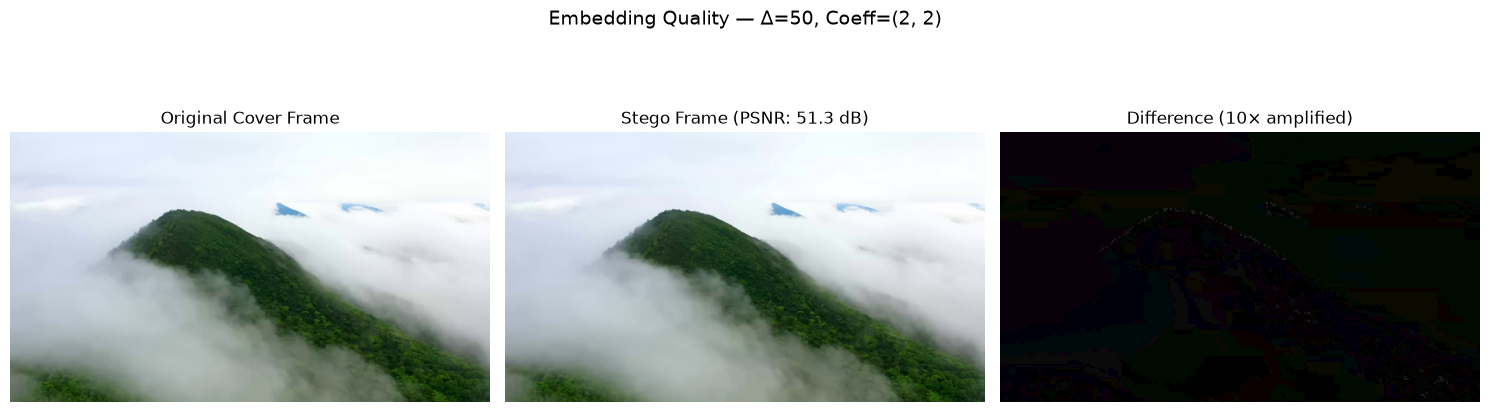

Saved: embedding_quality.png


In [15]:
# ── Visual comparison: original vs stego (first modified frame) ───────
first_mod_idx = next(i for i, s in enumerate(frame_stats) if s['status'] == 'modified')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original frame
axes[0].imshow(cv2.cvtColor(cover_frames[first_mod_idx], cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Cover Frame')
axes[0].axis('off')

# Stego frame
axes[1].imshow(cv2.cvtColor(stego_frames[first_mod_idx], cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Stego Frame (PSNR: {psnr_values[0]:.1f} dB)')
axes[1].axis('off')

# Difference map (amplified 10x for visibility)
diff = np.abs(cover_frames[first_mod_idx].astype(np.float64) -
              stego_frames[first_mod_idx].astype(np.float64))
diff_amplified = np.clip(diff * 10, 0, 255).astype(np.uint8)
axes[2].imshow(diff_amplified)
axes[2].set_title('Difference (10× amplified)')
axes[2].axis('off')

plt.suptitle(f'Embedding Quality — Δ={QIM_DELTA}, Coeff={COEFF_POS}', fontsize=14)
plt.tight_layout()
plt.savefig('embedding_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: embedding_quality.png")

## Section 9: Write Stego Video (Uncompressed)

Save the modified frames as an uncompressed AVI video. This raw stego
video preserves all the embedded data without any compression artifacts.
It serves as a reference point — extraction from this file should always
yield BER = 0%.

In [16]:
# ── Write uncompressed stego video ────────────────────────────────────
fourcc = cv2.VideoWriter_fourcc(*'MJPG')   # Use MJPG for near-lossless AVI
writer = cv2.VideoWriter(STEGO_RAW_PATH, fourcc, fps, (frame_w, frame_h))

for frame in stego_frames:
    writer.write(frame)

writer.release()

raw_size = os.path.getsize(STEGO_RAW_PATH)
print(f"Uncompressed stego video saved: '{STEGO_RAW_PATH}'")
print(f"  File size: {raw_size / 1024:.1f} KB ({raw_size / 1024 / 1024:.2f} MB)")
print(f"  Codec:     MJPG (near-lossless)")
print(f"  Frames:    {len(stego_frames)}")

Uncompressed stego video saved: 'stego_raw.avi'
  File size: 99865.9 KB (97.53 MB)
  Codec:     MJPG (near-lossless)
  Frames:    425


## Section 10: H.264 Compression (The Real Challenge)

This is where the rubber meets the road. H.264 compression is lossy —
it modifies pixel values, which perturbs our embedded DCT coefficients.
The QIM delta (Δ=50) and low-frequency coefficient position (2,2) were
chosen specifically to survive this perturbation.

We compress with FFmpeg using a **constant quantizer (`-qp`)**, not CRF.
CRF rate-control varies the quantizer per frame (it spends fewer bits on
frames it deems redundant), which destroyed the embedded coefficient on
every frame after the first. Constant QP quantizes every frame identically,
so the payload survives uniformly; we also force every frame to be an
I-frame (`keyint=1`) to avoid inter-prediction drift.

- **QP 18:** High quality, light compression → easiest for the bits to survive
- **QP 23:** Baseline test point
- **QP 28:** More aggressive → harder test

**Note:** FFmpeg must be installed. If not available, we fall back to
OpenCV's encoder (not QP-controlled — weaker resilience).

In [17]:
def compress_h264_ffmpeg(input_path, output_path, qp=23, preset='medium',
                         intra_only=True):
    """
    Compress with H.264 using a CONSTANT QUANTIZER (-qp), not CRF.

    CRF rate-control varies the quantizer per frame and crushed the embedded
    coefficient on all frames after the first. Constant QP quantizes every
    frame the same way, so the payload survives uniformly. intra_only=True
    additionally makes every frame an I-frame (no inter-prediction drift).
    """
    cmd = ['ffmpeg', '-y', '-i', input_path,
           '-c:v', 'libx264', '-qp', str(qp), '-preset', preset,
           '-pix_fmt', 'yuv420p']
    if intra_only:
        cmd += ['-x264-params', 'keyint=1:scenecut=0']
    cmd += [output_path]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=600)
        if result.returncode == 0:
            return True
        print(f"  FFmpeg error: {result.stderr[:200]}")
        return False
    except FileNotFoundError:
        print("  FFmpeg not found — install it or use the OpenCV fallback")
        return False
    except subprocess.TimeoutExpired:
        print("  FFmpeg timed out")
        return False


def compress_h264_opencv(stego_frames, output_path, fps, frame_w, frame_h):
    """Fallback only — not QP-controlled, weaker resilience. Prefer FFmpeg."""
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'),
                             fps, (frame_w, frame_h))
    for frame in stego_frames:
        writer.write(frame)
    writer.release()
    return True


print("Compression functions defined (constant QP).")


Compression functions defined (constant QP).


In [18]:
# ── Compress the stego video ──────────────────────────────────────────
print(f"Compressing with H.264 (QP={QP_VALUE}, preset={H264_PRESET})...")

success = compress_h264_ffmpeg(STEGO_RAW_PATH, STEGO_COMPRESSED, QP_VALUE,
                               H264_PRESET, intra_only=INTRA_ONLY)

if not success:
    print("Falling back to OpenCV compression...")
    success = compress_h264_opencv(stego_frames, STEGO_COMPRESSED, fps, frame_w, frame_h)

if success and os.path.exists(STEGO_COMPRESSED):
    comp_size = os.path.getsize(STEGO_COMPRESSED)
    print("="*70)
    print("  H.264 COMPRESSION COMPLETE")
    print("="*70)
    print(f"  Input:       {STEGO_RAW_PATH} ({raw_size/1024:.1f} KB)")
    print(f"  Output:      {STEGO_COMPRESSED} ({comp_size/1024:.1f} KB)")
    print(f"  Ratio:       {raw_size/comp_size:.1f}× compression")
    print(f"  QP:          {QP_VALUE}")
    print("="*70)
else:
    print("  ✗ Compression failed!")

Compressing with H.264 (QP=23, preset=medium)...
  H.264 COMPRESSION COMPLETE
  Input:       stego_raw.avi (99865.9 KB)
  Output:      stego_compressed.mp4 (99578.6 KB)
  Ratio:       1.0× compression
  QP:          23


# add audio


In [19]:
# ── Section 10b: Re-mux the original audio into the stego video ───────
# stego_compressed.mp4 is VIDEO-ONLY: the uncompressed .avi carried no
# audio, so libx264 wrote only a video stream. Before transmitting we copy
# the ORIGINAL audio track from the cover video back in. The critical flag
# is "-c:v copy": the H.264 video stream that carries the embedded payload
# is passed through byte-for-byte and is NOT re-encoded. Only the audio is
# muxed alongside, so the payload survives this step exactly (verified:
# frames stay pixel-identical). The resulting stego_final.mp4 is the file
# that actually gets sent over the channel.

STEGO_WITH_AUDIO = 'stego_final.mp4'      # <-- this is the file to transmit

def mux_audio(video_only_path, audio_source_path, output_path):
    """Combine the payload-carrying video stream with the cover's audio.
       Video is stream-copied (no re-encode); audio is (re)encoded to AAC
       for MP4. If the cover has no audio track, the video is copied through
       unchanged so the pipeline still produces a valid output."""
    probe = subprocess.run(
        ['ffprobe', '-i', audio_source_path, '-show_streams',
         '-select_streams', 'a', '-loglevel', 'error'],
        capture_output=True, text=True)
    has_audio = bool(probe.stdout.strip())

    if not has_audio:
        print("  Cover video has no audio track — copying video through unchanged.")
        cmd = ['ffmpeg', '-y', '-i', video_only_path, '-c', 'copy', output_path]
    else:
        cmd = ['ffmpeg', '-y',
               '-i', video_only_path,     # input 0: stego video (payload)
               '-i', audio_source_path,   # input 1: original cover (audio source)
               '-map', '0:v:0',           # video  <- input 0
               '-map', '1:a:0',           # audio  <- input 1
               '-c:v', 'copy',            # DO NOT re-encode video (payload safe)
               '-c:a', 'aac',             # audio -> AAC for the MP4 container
               '-shortest',
               output_path]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=600)
    return result.returncode == 0, result.stderr

print(f"Muxing original audio from '{COVER_VIDEO_PATH}' into the stego video...")
ok, err = mux_audio(STEGO_COMPRESSED, COVER_VIDEO_PATH, STEGO_WITH_AUDIO)

if ok and os.path.exists(STEGO_WITH_AUDIO):
    print("="*70)
    print("  AUDIO RE-MUX COMPLETE — stego_final.mp4 is the file to transmit")
    print("="*70)
    print(f"  Video (payload):  {STEGO_COMPRESSED}  (stream copied verbatim)")
    print(f"  Audio source:     {COVER_VIDEO_PATH}")
    print(f"  Final output:     {STEGO_WITH_AUDIO} "
          f"({os.path.getsize(STEGO_WITH_AUDIO)/1024:.1f} KB)")
    print("="*70)
else:
    print("  ✗ Audio mux failed:")
    print(err[:300])

Muxing original audio from 'cover_video.mp4' into the stego video...
  AUDIO RE-MUX COMPLETE — stego_final.mp4 is the file to transmit
  Video (payload):  stego_compressed.mp4  (stream copied verbatim)
  Audio source:     cover_video.mp4
  Final output:     stego_final.mp4 (99435.0 KB)


## Section 11: Post-Compression Extraction Test

This is the **critical test** — can we recover the payload after H.264
compression? We load the compressed video and extract the bits using the
**sender's** ROI masks (the same masks used for embedding). The real
receiver (Module 5) also uses these transmitted masks — the system is
non-blind — so this test faithfully mirrors the receiver.

A small residual BER here is expected and fine: the Reed-Solomon FEC layer
(decoded in Module 6) corrects it to a byte-exact ciphertext. To *reduce*
the raw BER you would lower QP; to *correct* more of it you would raise
`RS_PARITY` in `fec_module.py`. The pipeline succeeds as long as the BER
stays within the FEC budget.

In [20]:
# ── Load compressed stego video ───────────────────────────────────────
comp_frames, _, _, _ = extract_frames(STEGO_COMPRESSED)

print(f"Compressed stego video loaded: {len(comp_frames)} frames")
print(f"Extracting payload from compressed frames...")

# ── Extract bits from compressed frames ───────────────────────────────
# Extraction uses the SENDER'S ROI masks (the same ones used to embed).
# The system is non-blind: roi_masks.npy is transmitted as side-info, and
# Module 5 uses these exact masks too. Sequential QIM embedding requires
# exact block alignment, which only the transmitted masks guarantee
# (receiver-side regeneration agrees only ~97%, which desynchronizes
# the bitstream — see the Module 5 diagnostic).

comp_extracted_bits = []
bits_remaining = len(payload_bits)

for i in range(len(comp_frames)):
    if bits_remaining <= 0:
        break
    
    bits_in_frame = frame_stats[i]['bits_embedded']
    if bits_in_frame == 0:
        continue
    
    # Use the sender's ROI mask (Module 5 uses these same masks; non-blind)
    extracted = extract_from_frame(
        comp_frames[i], roi_masks[i], bits_in_frame,
        block_size=BLOCK_SIZE, coeff_pos=COEFF_POS, delta=QIM_DELTA,
        channel=EMBED_CHANNEL
    )
    comp_extracted_bits.extend(extracted)
    bits_remaining -= len(extracted)

comp_extracted_array = np.array(comp_extracted_bits, dtype=np.uint8)

# Calculate post-compression BER
comp_errors = np.sum(comp_extracted_array != payload_bits[:len(comp_extracted_array)])
comp_ber = comp_errors / len(comp_extracted_array) * 100 if len(comp_extracted_array) > 0 else 0

print("="*70)
print(f"  POST-COMPRESSION EXTRACTION TEST (QP={QP_VALUE})")
print("="*70)
print(f"  Bits extracted:   {len(comp_extracted_array)} / {len(payload_bits)}")
print(f"  Bit errors:       {comp_errors}")
print(f"  BER:              {comp_ber:.4f}%")
if comp_ber == 0:
    print(f"  ✓ ZERO raw BER — payload survives H.264 at QP {QP_VALUE} exactly!")
elif comp_ber < 5.0:
    print(f"  ✓ Low raw BER ({comp_ber:.4f}%) — within the Reed-Solomon FEC budget;")
    print(f"    Module 6 corrects it to a byte-exact ciphertext.")
else:
    print(f"  ✗ High BER ({comp_ber:.4f}%) — likely beyond FEC; lower QP or raise RS_PARITY")
print("="*70)

Compressed stego video loaded: 425 frames
Extracting payload from compressed frames...
  POST-COMPRESSION EXTRACTION TEST (QP=23)
  Bits extracted:   795600 / 795600
  Bit errors:       1440
  BER:              0.1810%
  ✓ Low raw BER (0.1810%) — within the Reed-Solomon FEC budget;
    Module 6 corrects it to a byte-exact ciphertext.


## Section 12: Delta (Δ) Sensitivity Analysis

Test different Δ values to find the optimal trade-off between robustness
(low BER after compression) and imperceptibility (high PSNR).

This analysis embeds and extracts with various Δ values on the first
frame to provide quick guidance for parameter tuning.

In [21]:
# ── Test multiple delta values on frame 0 ─────────────────────────────
delta_values = [10, 15, 20, 25, 30, 40, 50]
delta_results = []

# Use only the bits that fit in frame 0
frame0_roi_count = int(np.sum(roi_masks[0]))
test_bits = payload_bits[:frame0_roi_count]

print("="*70)
print("  DELTA (Δ) SENSITIVITY ANALYSIS (Frame 0)")
print("="*70)
print(f"  Test bits: {len(test_bits)} (from first frame ROI blocks)")
print(f"")
print(f"  {'Δ':>5} | {'PSNR (dB)':>10} | {'SSIM':>8} | {'Note':>20}")
print(f"  {'-'*5}-+-{'-'*10}-+-{'-'*8}-+-{'-'*20}")

for d in delta_values:
    # Embed with this delta
    stego_test, _, _ = embed_in_frame(
        cover_frames[0], roi_masks[0], test_bits, 0,
        block_size=BLOCK_SIZE, coeff_pos=COEFF_POS, delta=d,
        channel=EMBED_CHANNEL
    )
    
    # Measure quality
    psnr_val = calculate_psnr(cover_frames[0], stego_test)
    ssim_val = calculate_ssim(cover_frames[0], stego_test)
    
    # Determine note
    if psnr_val > 40:
        note = "Excellent quality"
    elif psnr_val > 35:
        note = "Good quality"
    elif psnr_val > 30:
        note = "Acceptable"
    else:
        note = "Visible artifacts"
    
    marker = " ←" if d == QIM_DELTA else ""
    print(f"  {d:>5} | {psnr_val:>10.2f} | {ssim_val:>8.5f} | {note:>20}{marker}")
    
    delta_results.append({
        'delta': d, 'psnr': psnr_val, 'ssim': ssim_val
    })

print("="*70)

  DELTA (Δ) SENSITIVITY ANALYSIS (Frame 0)
  Test bits: 254 (from first frame ROI blocks)

      Δ |  PSNR (dB) |     SSIM |                 Note
  ------+------------+----------+---------------------
     10 |      51.56 |  0.99930 |    Excellent quality
     15 |      51.55 |  0.99929 |    Excellent quality
     20 |      51.53 |  0.99928 |    Excellent quality
     25 |      51.49 |  0.99927 |    Excellent quality
     30 |      51.44 |  0.99924 |    Excellent quality
     40 |      51.38 |  0.99921 |    Excellent quality
     50 |      51.26 |  0.99916 |    Excellent quality ←


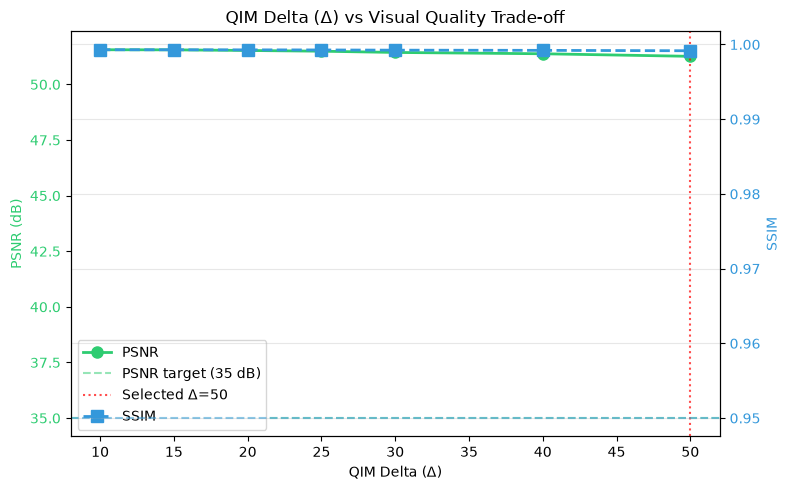

Saved: delta_tradeoff.png


In [22]:
# ── Plot Delta vs PSNR trade-off ──────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(8, 5))

deltas = [r['delta'] for r in delta_results]
psnrs  = [r['psnr'] for r in delta_results]
ssims  = [r['ssim'] for r in delta_results]

# PSNR on left axis
color1 = '#2ecc71'
ax1.plot(deltas, psnrs, 'o-', color=color1, linewidth=2, markersize=8, label='PSNR')
ax1.axhline(y=35, color=color1, linestyle='--', alpha=0.5, label='PSNR target (35 dB)')
ax1.axvline(x=QIM_DELTA, color='red', linestyle=':', alpha=0.7, label=f'Selected Δ={QIM_DELTA}')
ax1.set_xlabel('QIM Delta (Δ)')
ax1.set_ylabel('PSNR (dB)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# SSIM on right axis
ax2 = ax1.twinx()
color2 = '#3498db'
ax2.plot(deltas, ssims, 's--', color=color2, linewidth=2, markersize=8, label='SSIM')
ax2.axhline(y=0.95, color=color2, linestyle='--', alpha=0.5)
ax2.set_ylabel('SSIM', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.title('QIM Delta (Δ) vs Visual Quality Trade-off')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('delta_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: delta_tradeoff.png")

## Section 13: DCT Coefficient Visualization

Visualize the DCT coefficient matrix of a sample block before and after
embedding, showing exactly which coefficient was modified and by how much.
This is useful for understanding and explaining the embedding mechanism
in your thesis.

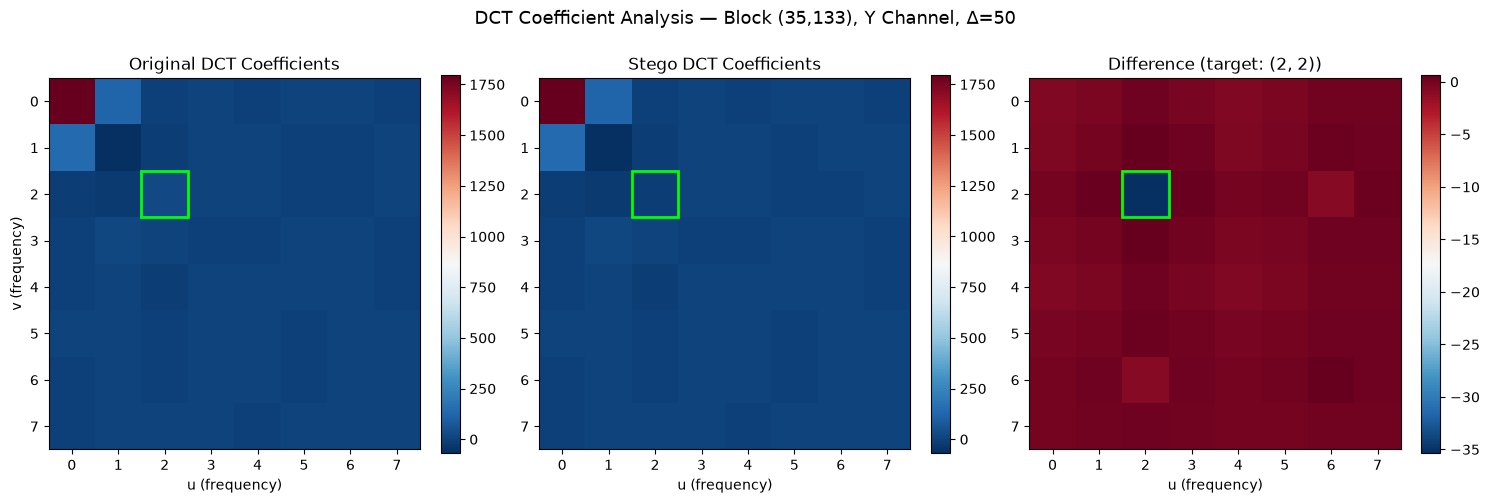

  Target coefficient at position (2, 2):
    Original:  23.5940
    Modified:  -11.7238
    Change:    -35.3178
    Embedded bit: 0

Saved: dct_coefficient_analysis.png


In [23]:
# ── Show DCT coefficients before/after for one block ──────────────────
# Find the first ROI block in frame 0
first_roi_by, first_roi_bx = None, None
for by in range(roi_masks[0].shape[0]):
    for bx in range(roi_masks[0].shape[1]):
        if roi_masks[0][by, bx] == 1:
            first_roi_by, first_roi_bx = by, bx
            break
    if first_roi_by is not None:
        break

if first_roi_by is not None:
    # Extract block from original and stego frames
    y_s = first_roi_by * BLOCK_SIZE
    x_s = first_roi_bx * BLOCK_SIZE
    
    orig_ycrcb = cv2.cvtColor(cover_frames[0], cv2.COLOR_BGR2YCrCb)
    steg_ycrcb = cv2.cvtColor(stego_frames[0], cv2.COLOR_BGR2YCrCb)
    
    orig_block = orig_ycrcb[y_s:y_s+8, x_s:x_s+8, EMBED_CHANNEL].astype(np.float64)
    steg_block = steg_ycrcb[y_s:y_s+8, x_s:x_s+8, EMBED_CHANNEL].astype(np.float64)
    
    orig_dct = apply_dct_2d(orig_block)
    steg_dct = apply_dct_2d(steg_block)
    diff_dct = steg_dct - orig_dct
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    im0 = axes[0].imshow(orig_dct, cmap='RdBu_r', interpolation='nearest')
    axes[0].set_title('Original DCT Coefficients')
    axes[0].set_xlabel('u (frequency)')
    axes[0].set_ylabel('v (frequency)')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    im1 = axes[1].imshow(steg_dct, cmap='RdBu_r', interpolation='nearest')
    axes[1].set_title('Stego DCT Coefficients')
    axes[1].set_xlabel('u (frequency)')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    im2 = axes[2].imshow(diff_dct, cmap='RdBu_r', interpolation='nearest')
    axes[2].set_title(f'Difference (target: {COEFF_POS})')
    axes[2].set_xlabel('u (frequency)')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    # Mark the target coefficient
    for ax in axes:
        rect = plt.Rectangle((COEFF_POS[1]-0.5, COEFF_POS[0]-0.5), 1, 1,
                             linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
    
    plt.suptitle(f'DCT Coefficient Analysis — Block ({first_roi_by},{first_roi_bx}), '
                 f'Y Channel, Δ={QIM_DELTA}', fontsize=13)
    plt.tight_layout()
    plt.savefig('dct_coefficient_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print the exact coefficient values
    u, v = COEFF_POS
    print(f"  Target coefficient at position {COEFF_POS}:")
    print(f"    Original:  {orig_dct[u, v]:.4f}")
    print(f"    Modified:  {steg_dct[u, v]:.4f}")
    print(f"    Change:    {diff_dct[u, v]:+.4f}")
    print(f"    Embedded bit: {payload_bits[0]}")
    print(f"")
    print("Saved: dct_coefficient_analysis.png")

## Section 14: Save Embedding Metadata

Save all embedding parameters and statistics so Module 5 (extraction)
and Module 7 (benchmarking) have the exact values they need.

In [24]:
# ── Save embedding metadata ───────────────────────────────────────────
EMBED_META_FILE = 'embedding_metadata.npy'

embedding_metadata = {
    # Embedding parameters (MUST match extraction)
    'block_size':       BLOCK_SIZE,
    'coeff_pos':        COEFF_POS,
    'qim_delta':        QIM_DELTA,
    'channel':          EMBED_CHANNEL,
    
    # Payload info
    'payload_bits':     len(payload_bits),
    'payload_bytes':    len(ciphertext_blob),
    'ciphertext_file':  CIPHERTEXT_FILE,
    
    # Per-frame bit counts (needed by extractor to know how many bits per frame)
    'bits_per_frame':   [s['bits_embedded'] for s in frame_stats],
    
    # Video info
    'stego_raw':        STEGO_RAW_PATH,
    'stego_compressed': STEGO_COMPRESSED,
    'qp':               QP_VALUE,
    'h264_preset':      H264_PRESET,
    'fps':              fps,
    'frame_width':      frame_w,
    'frame_height':     frame_h,
    'total_frames':     len(cover_frames),
    'modified_frames':  modified_frames,
    
    # Quality metrics
    'avg_psnr':         avg_psnr,
    'avg_ssim':         avg_ssim,
    'pre_comp_ber':     ber,
    'post_comp_ber':    comp_ber
}

np.save(EMBED_META_FILE, embedding_metadata)
print(f"Embedding metadata saved to '{EMBED_META_FILE}'")

Embedding metadata saved to 'embedding_metadata.npy'


## Section 15: Summary

Displays a complete summary of Module 4 outputs for pipeline verification.

In [25]:
print("▓"*70)
print("  MODULE 4 COMPLETE — DCT-QIM Embedding (Compression-Resilient)")
print("▓"*70)
print(f"")
print(f"  Input:")
print(f"    Ciphertext:         {CIPHERTEXT_FILE} ({len(ciphertext_blob)} bytes, {len(payload_bits)} bits)")
print(f"    ROI masks:          {ROI_MASKS_FILE} ({roi_masks.shape})")
print(f"    Cover video:        {COVER_VIDEO_PATH} ({frame_w}×{frame_h}, {len(cover_frames)} frames)")
print(f"")
print(f"  Embedding Parameters:")
print(f"    Color channel:      {EMBED_CHANNEL} = {CHAN_NAME[EMBED_CHANNEL]}")
print(f"    Block size:         {BLOCK_SIZE}×{BLOCK_SIZE}")
print(f"    DCT coefficient:    position {COEFF_POS} (low-frequency)")
print(f"    QIM delta (Δ):      {QIM_DELTA}")
print(f"    Embedding scheme:   c' = Δ×round(c/Δ) + (-1)^(1-b) × (Δ/4)")
print(f"")
print(f"  Embedding Results:")
print(f"    Total bits embedded:    {total_embedded} / {len(payload_bits)}")
print(f"    Frames modified:        {modified_frames} / {len(cover_frames)}")
print(f"    Pre-compression BER:    {ber:.4f}% {'✓' if ber == 0 else '✗'}")
print(f"    Post-compression BER:   {comp_ber:.4f}% {'✓' if comp_ber == 0 else '⚠'}")
print(f"")
print(f"  Visual Quality:")
print(f"    Average PSNR:           {avg_psnr:.2f} dB {'✓' if avg_psnr > 35 else '⚠'} (target > 35 dB)")
print(f"    Average SSIM:           {avg_ssim:.6f} {'✓' if avg_ssim > 0.95 else '⚠'} (target > 0.95)")
print(f"")
print(f"  Compression:")
print(f"    Codec:                  H.264 (libx264)")
print(f"    QP:                     {QP_VALUE}")
print(f"    Raw size:               {raw_size/1024:.1f} KB")
if os.path.exists(STEGO_COMPRESSED):
    comp_size = os.path.getsize(STEGO_COMPRESSED)
    print(f"    Compressed size:        {comp_size/1024:.1f} KB ({raw_size/comp_size:.1f}× ratio)")
print(f"")
print(f"  Output Files:")
print(f"    Stego (raw):            {STEGO_RAW_PATH}")
print(f"    Stego (compressed):     {STEGO_COMPRESSED}")
print(f"    Embedding metadata:     {EMBED_META_FILE}")
print(f"")
print(f"  Figures saved:")
print(f"    embedding_quality.png        — Original vs Stego comparison")
print(f"    delta_tradeoff.png           — Δ vs PSNR/SSIM trade-off")
print(f"    dct_coefficient_analysis.png — DCT coefficient visualization")
print(f"")
print("="*70)
print(f"  MODULE 4 OUTPUT → '{STEGO_COMPRESSED}' ready for transmission")
print(f"  MODULE 4 OUTPUT → '{EMBED_META_FILE}' needed by Module 5 (Extraction)")
print("="*70)

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  MODULE 4 COMPLETE — DCT-QIM Embedding (Compression-Resilient)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  Input:
    Ciphertext:         fec_payload.bin (99450 bytes, 795600 bits)
    ROI masks:          roi_masks.npy ((425, 135, 240))
    Cover video:        cover_video.mp4 (1920×1080, 425 frames)

  Embedding Parameters:
    Color channel:      0 = Y (luminance)
    Block size:         8×8
    DCT coefficient:    position (2, 2) (low-frequency)
    QIM delta (Δ):      50
    Embedding scheme:   c' = Δ×round(c/Δ) + (-1)^(1-b) × (Δ/4)

  Embedding Results:
    Total bits embedded:    795600 / 795600
    Frames modified:        177 / 425
    Pre-compression BER:    0.0000% ✓
    Post-compression BER:   0.1810% ⚠

  Visual Quality:
    Average PSNR:           48.94 dB ✓ (target > 35 dB)
    Average SSIM:           0.997277 ✓ (target > 0.95)

  Compression:
    Codec:                  H.